# MLTS — Lecture 5 Practice
## Gaussian Process Classification

This notebook accompanies **Lecture 5** of the MLTS course summary. We extend the GP
machinery from L4 to *classification*, where the outputs are discrete labels $y \in \{-1, +1\}$
instead of real values.

The fundamental change: a sigmoid-squashed Gaussian likelihood **breaks conjugacy**, so
the posterior is no longer Gaussian and we need approximations.

**You will learn how to:**
1. Frame classification as a 2-step process: latent GP $f$ → sigmoid → class probability.
2. Choose between **logistic** and **probit** sigmoids (and understand why neither one
   gives you a closed-form posterior).
3. See *empirically* why $p(f \mid y)$ is non-Gaussian.
4. Implement the **Laplace approximation** from scratch — Newton-Raphson finds the
   posterior mode, then we fit a Gaussian at it.
5. Use `sklearn`'s `GaussianProcessClassifier` end-to-end and read the predictive
   probabilities and uncertainty.

**Prerequisites:** `numpy`, `scipy`, `matplotlib`, `scikit-learn`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import cho_factor, cho_solve, cholesky

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1 · Regression vs classification

Same input space, different output space:

| | Regression (L4) | Classification (L5) |
|---|---|---|
| Inputs $x$ | $\mathbb{R}^d$ | $\mathbb{R}^d$ |
| Outputs $y$ | $\mathbb{R}$ | $\{-1, +1\}$ |
| Goal | $f(x)$ | $\pi(x) = p(y = +1 \mid x) \in [0, 1]$ |
| Likelihood | $\mathcal{N}(y \mid f, \sigma_n^2)$ — Gaussian | $\sigma(y \cdot f)$ — Bernoulli with sigmoid link |
| Posterior | Gaussian (closed form) | Non-Gaussian (needs approximation) |


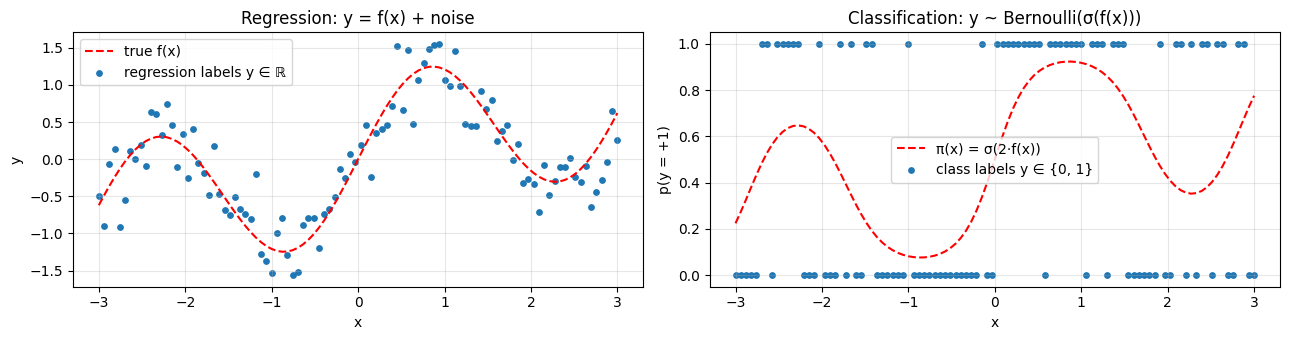

Same underlying f(x) — completely different observation models.


In [2]:
# Visualise the difference
xs = np.linspace(-3, 3, 100)
true_fn = np.sin(2*xs) + 0.3*xs

# Regression labels: noisy real values
y_reg = true_fn + rng.normal(0, 0.4, len(xs))

# Classification labels: ±1 with probability sigmoid(true_fn)
def logistic(z): return 1.0 / (1.0 + np.exp(-z))
probs = logistic(2 * true_fn)
y_cls = np.where(rng.uniform(size=len(xs)) < probs, 1, -1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(xs, true_fn, 'r--', lw=1.5, label='true f(x)')
axes[0].scatter(xs, y_reg, s=15, color='C0', label='regression labels y ∈ ℝ')
axes[0].set_title('Regression: y = f(x) + noise')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

axes[1].plot(xs, probs, 'r--', lw=1.5, label='π(x) = σ(2·f(x))')
axes[1].scatter(xs, (y_cls + 1) / 2, s=15, color='C0',
                label='class labels y ∈ {0, 1}')
axes[1].set_title('Classification: y ~ Bernoulli(σ(f(x)))')
axes[1].set_xlabel('x'); axes[1].set_ylabel('p(y = +1)'); axes[1].legend()
plt.tight_layout(); plt.show()

print("Same underlying f(x) — completely different observation models.")


## 2 · The sigmoid

Two common choices to squash a real number into $[0, 1]$:

| Name | Formula | Where it comes from |
|------|---------|---------------------|
| **Logistic** | $\lambda(z) = \dfrac{1}{1 + e^{-z}}$ | Softmax over 2 classes |
| **Probit** | $\Phi(z) = \int_{-\infty}^z \mathcal{N}(u \mid 0, 1)\, du$ | Normal CDF |

Both are **symmetric**: $\sigma(-z) = 1 - \sigma(z)$. This symmetry lets us write the
likelihood for either label compactly:

$$p(y_i \mid f_i) = \sigma(y_i f_i), \quad y_i \in \{-1, +1\}.$$

Logistic and probit look almost identical; the choice rarely matters in practice. Logistic
has a simpler analytical gradient (used in Laplace), probit has a closed-form expression
for $\int \Phi(f) \mathcal{N}(f) df$ (useful for the predictive integral).


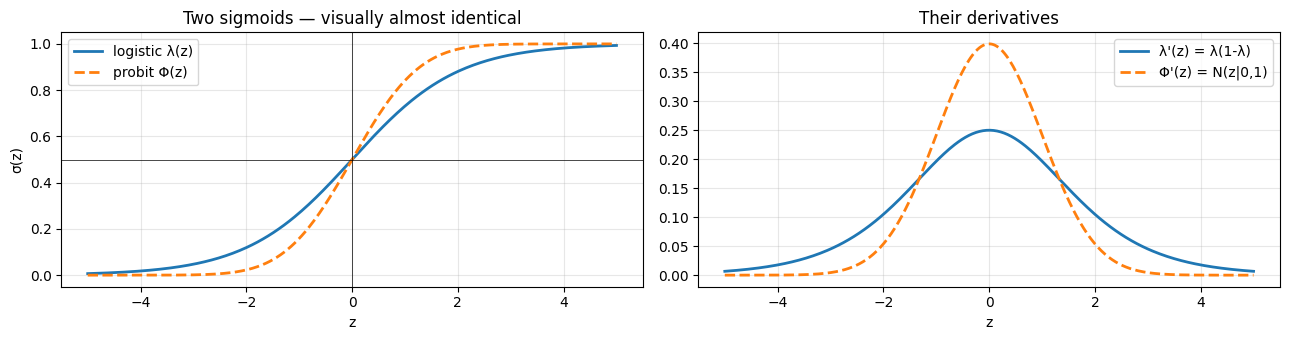

Calibration scaling between the two:
  λ(z) ≈ Φ(z·√(8/π)/2) ≈ Φ(z · 0.6266) — fits well around z=0.
  At z=1: λ=0.7311, Φ(0.6266)=0.7345


In [3]:
def logistic(z): return 1.0 / (1.0 + np.exp(-z))
def probit(z):   return stats.norm.cdf(z)

zs = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(zs, logistic(zs), label='logistic λ(z)', lw=2)
axes[0].plot(zs, probit(zs),   label='probit Φ(z)',  lw=2, ls='--')
axes[0].axhline(0.5, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].legend(); axes[0].set_title('Two sigmoids — visually almost identical')
axes[0].set_xlabel('z'); axes[0].set_ylabel('σ(z)')

# Gradient comparison
axes[1].plot(zs, logistic(zs) * (1 - logistic(zs)), label="λ'(z) = λ(1-λ)", lw=2)
axes[1].plot(zs, stats.norm.pdf(zs),                label="Φ'(z) = N(z|0,1)", lw=2, ls='--')
axes[1].legend(); axes[1].set_title('Their derivatives')
axes[1].set_xlabel('z')
plt.tight_layout(); plt.show()

# Quantitative comparison
print("Calibration scaling between the two:")
print(f"  λ(z) ≈ Φ(z·√(8/π)/2) ≈ Φ(z · 0.6266) — fits well around z=0.")
print(f"  At z=1: λ={logistic(1):.4f}, Φ(0.6266)={probit(0.6266):.4f}")


## 3 · The two-step model — prior samples

The lecture's key picture:

**Step 1.** Place a GP prior over a *latent* function $f \sim GP(0, k)$.
**Step 2.** Squash $f$ through a sigmoid to get the class probability $\pi(x) = \sigma(f(x))$.

The data $y_i$ are then sampled as $y_i \sim \text{Bernoulli}(\pi(x_i))$.

We sample functions from the prior at each stage to make this concrete.


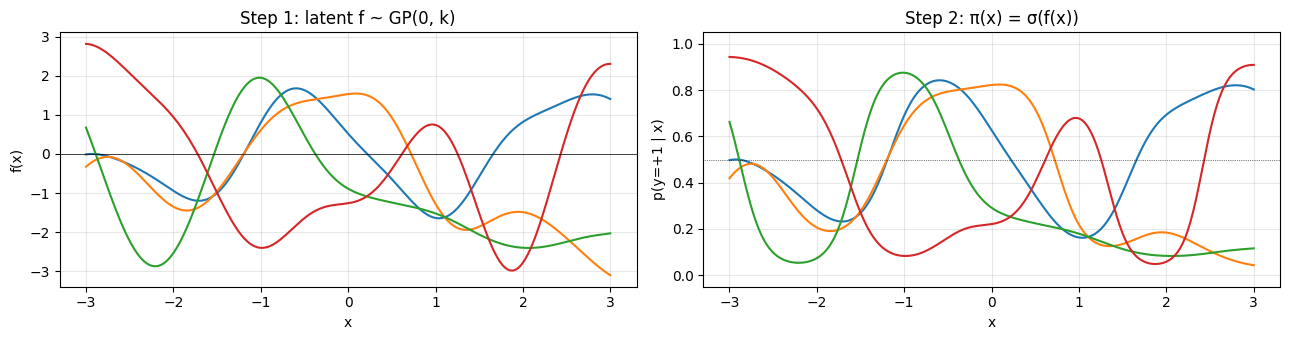

f crosses zero → π crosses 0.5 → decision boundary.
|f| large → π saturates near 0 or 1 → confident prediction.


In [4]:
def rbf_kernel(t1, t2, ell=1.0, sigma_f=1.0):
    t1 = np.atleast_1d(t1).reshape(-1, 1); t2 = np.atleast_1d(t2).reshape(1, -1)
    return sigma_f**2 * np.exp(-0.5 * (t1 - t2)**2 / ell**2)

def sample_gp_prior(t, kernel_fn, n_samples=5, jitter=1e-8):
    K = kernel_fn(t, t) + jitter * np.eye(len(t))
    L = cholesky(K, lower=True)
    return L @ rng.normal(size=(len(t), n_samples))

xs = np.linspace(-3, 3, 200)
f_samples = sample_gp_prior(xs, lambda a, b: rbf_kernel(a, b, ell=0.7, sigma_f=2.0),
                            n_samples=4)
pi_samples = logistic(f_samples)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for k in range(f_samples.shape[1]):
    axes[0].plot(xs, f_samples[:, k], lw=1.5)
    axes[1].plot(xs, pi_samples[:, k], lw=1.5)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Step 1: latent f ~ GP(0, k)'); axes[0].set_ylabel('f(x)')
axes[1].axhline(0.5, color='k', lw=0.5, ls=':')
axes[1].set_title('Step 2: π(x) = σ(f(x))'); axes[1].set_ylabel('p(y=+1 | x)')
axes[1].set_ylim(-0.05, 1.05)
for ax in axes: ax.set_xlabel('x')
plt.tight_layout(); plt.show()

print("f crosses zero → π crosses 0.5 → decision boundary.")
print("|f| large → π saturates near 0 or 1 → confident prediction.")


## 4 · Why the posterior over $f$ is non-Gaussian

For regression the likelihood was Gaussian, so prior × likelihood = Gaussian. **Not so
for classification.** With sigmoid likelihood:

$$p(f \mid y, X) \propto \underbrace{p(f \mid X)}_{\text{Gaussian prior}} \cdot \underbrace{\prod_i \sigma(y_i f_i)}_{\text{non-Gaussian}}.$$

The product is no longer in any standard family. We can see this empirically — let's
look at the posterior for a single test point given a 1D dataset.


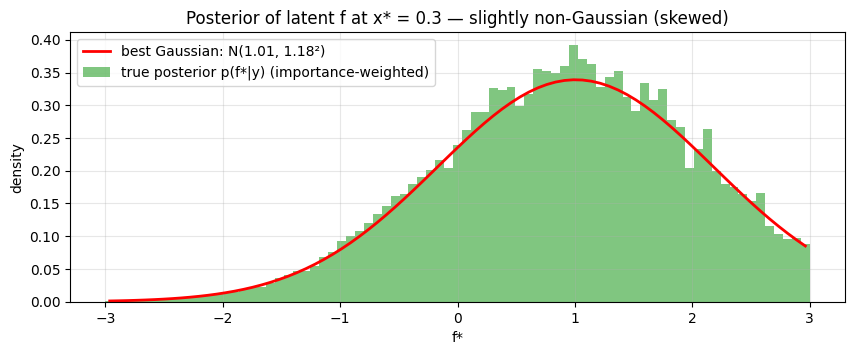

Posterior mean  = 1.005
Posterior std   = 1.177
Effective sample size: 13,343 / 50,000 (27%)

With this much data and a smooth latent function the posterior is *close* to
Gaussian. With more extreme labels or near a sharp decision boundary the
deviation grows. The Laplace approximation in section 5 fits a Gaussian at the
posterior mode — a much better strategy than method-of-moments.


In [5]:
# Tiny dataset: 5 training points
x_train = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
y_train = np.array([-1,   -1,    1,    1,   1])     # threshold around x=0

# Look at the posterior over f at a single test point x* = 0.3
x_star = 0.3

# To plot p(f_* | y, X), use the joint p(f_train, f_*) ~ N(0, K_aug),
# multiply by likelihood ∏σ(y_i f_train_i) and marginalise over f_train.
# We'll use simple Monte-Carlo: sample lots of (f_train, f_*) from the prior,
# weight each by the likelihood, then build a weighted histogram of f_*.

ell, sf = 1.0, 1.5
all_x = np.concatenate([x_train, [x_star]])
K = rbf_kernel(all_x, all_x, ell=ell, sigma_f=sf) + 1e-6 * np.eye(len(all_x))
L = cholesky(K, lower=True)

n_mc = 50000
samples_joint = L @ rng.normal(size=(len(all_x), n_mc))
f_train_samps = samples_joint[:5]
f_star_samps  = samples_joint[5]

# Weight each sample by likelihood: ∏ σ(y_i * f_train_i)
log_w = np.sum(np.log(logistic(y_train[:, None] * f_train_samps)), axis=0)
log_w -= log_w.max()
w = np.exp(log_w)
w /= w.sum()

# Effective sample size
ess = 1.0 / np.sum(w**2)

# Build weighted histogram for the posterior of f_star
bins = np.linspace(-3, 3, 80)
hist, edges = np.histogram(f_star_samps, bins=bins, weights=w, density=True)
centres = 0.5 * (edges[:-1] + edges[1:])

# Best-fit Gaussian (by moments) for comparison
post_mean = np.sum(w * f_star_samps)
post_var  = np.sum(w * (f_star_samps - post_mean)**2)
gauss_fit = stats.norm.pdf(centres, post_mean, np.sqrt(post_var))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(centres, hist, width=edges[1]-edges[0], alpha=0.6, color='C2',
       label='true posterior p(f*|y) (importance-weighted)')
ax.plot(centres, gauss_fit, 'r-', lw=2,
        label=f'best Gaussian: N({post_mean:.2f}, {np.sqrt(post_var):.2f}²)')
ax.set_xlabel('f*'); ax.set_ylabel('density'); ax.legend()
ax.set_title(f'Posterior of latent f at x* = {x_star} — slightly non-Gaussian (skewed)')
plt.show()

print(f"Posterior mean  = {post_mean:.3f}")
print(f"Posterior std   = {np.sqrt(post_var):.3f}")
print(f"Effective sample size: {ess:,.0f} / {n_mc:,} ({100*ess/n_mc:.0f}%)")
print()
print("With this much data and a smooth latent function the posterior is *close* to")
print("Gaussian. With more extreme labels or near a sharp decision boundary the")
print("deviation grows. The Laplace approximation in section 5 fits a Gaussian at the")
print("posterior mode — a much better strategy than method-of-moments.")


## 5 · Laplace approximation from scratch

The standard fix for non-Gaussian posteriors: fit a Gaussian centred at the posterior
mode, with covariance equal to the inverse Hessian of the negative log-posterior at the
mode. For GP classification with logistic likelihood:

$$\hat f = \arg\max_f \log p(f \mid y, X) = \arg\max_f \Big[\log p(y \mid f) - \tfrac{1}{2} f^\top K^{-1} f\Big]$$

The mode is found by **Newton-Raphson** iteration. Define $\pi_i = \sigma(f_i)$, then:

- gradient of $\log p(y\mid f)$:  $\nabla \log p(y\mid f) = \frac{y+1}{2} - \pi$ (for labels in $\{-1,+1\}$, equivalent to $t-\pi$ where $t = (y+1)/2$)
- Hessian:                    $W = \text{diag}(\pi(1-\pi))$ — always positive, which guarantees a unique mode.

The Newton update (Rasmussen & Williams 3.4):
$$f_{\text{new}} = (K^{-1} + W)^{-1}(W f + \nabla \log p(y\mid f)).$$

We implement it below.


Laplace mode f̂        = [-2.069 -2.513 -2.365 -1.43   1.43   2.365  2.513  2.069]
log marginal likelihood = -3.941


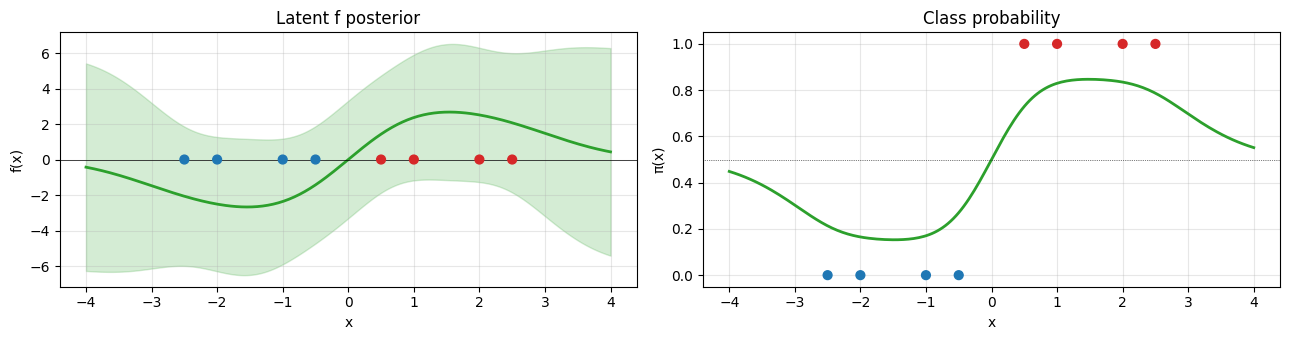

In [6]:
def laplace_mode(K, y, max_iter=50, tol=1e-7):
    """Find the posterior mode for binary GP classification (logistic).
    y in {-1, +1}; K is the train-train kernel matrix.
    Returns (f_hat, W_diag, log_marginal_likelihood_approx)."""
    n = len(y)
    t = (y + 1) / 2.0       # convert to {0, 1}
    f = np.zeros(n)
    K_with_jitter = K + 1e-7 * np.eye(n)
    log_marg_old = -np.inf
    for it in range(max_iter):
        pi = logistic(f)
        W = pi * (1 - pi)
        sqrtW = np.sqrt(W)
        # B = I + sqrt(W) K sqrt(W)
        B = np.eye(n) + sqrtW[:, None] * K_with_jitter * sqrtW[None, :]
        L = cholesky(B, lower=True)
        b = W * f + (t - pi)
        a = b - sqrtW * cho_solve((L, True), sqrtW * (K_with_jitter @ b))
        f = K_with_jitter @ a
        # Approximate log marginal likelihood (Rasmussen & Williams eq 3.32)
        log_p_y_given_f = np.sum(np.log(logistic(y * f)))
        log_marg = (-0.5 * a @ f
                    + log_p_y_given_f
                    - np.sum(np.log(np.diag(L))))
        if abs(log_marg - log_marg_old) < tol:
            break
        log_marg_old = log_marg
    return f, W, log_marg

def laplace_predict(K, K_s, K_ss, y, f_hat, W):
    """Posterior predictive for latent f* using Laplace approximation."""
    sqrtW = np.sqrt(W)
    n = len(y)
    B = np.eye(n) + sqrtW[:, None] * K * sqrtW[None, :]
    L = cholesky(B, lower=True)
    t = (y + 1) / 2.0
    pi = logistic(f_hat)
    f_star_mean = K_s.T @ (t - pi)              # latent posterior mean
    v = cho_solve((L, True), sqrtW[:, None] * K_s)
    f_star_var = np.diag(K_ss) - np.sum((sqrtW[:, None] * K_s) * v, axis=0)
    f_star_var = np.maximum(f_star_var, 0)       # numerical floor
    return f_star_mean, f_star_var

def class_predict_probit(f_mean, f_var):
    """Approximate ∫ σ(f*) N(f*|μ, σ²) df* using probit closed form."""
    # Replace logistic with probit using calibration factor
    kappa = 1.0 / np.sqrt(1.0 + np.pi * f_var / 8.0)
    return logistic(kappa * f_mean)

# 1D demo
x_train = np.array([-2.5, -2.0, -1.0, -0.5, 0.5, 1.0, 2.0, 2.5])
y_train = np.array([-1,   -1,   -1,   -1,    1,   1,   1,   1])

ell, sf = 1.0, 3.0
K = rbf_kernel(x_train, x_train, ell=ell, sigma_f=sf)
f_hat, W, lml = laplace_mode(K, y_train)
print(f"Laplace mode f̂        = {np.round(f_hat, 3)}")
print(f"log marginal likelihood = {lml:.3f}")

# Predict on a grid
xs_grid = np.linspace(-4, 4, 200)
K_s  = rbf_kernel(x_train, xs_grid, ell=ell, sigma_f=sf)
K_ss = rbf_kernel(xs_grid, xs_grid, ell=ell, sigma_f=sf)
f_mean, f_var = laplace_predict(K, K_s, K_ss, y_train, f_hat, W)
prob_pos = class_predict_probit(f_mean, f_var)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
# Latent posterior over f
f_std = np.sqrt(f_var)
axes[0].fill_between(xs_grid, f_mean - 2*f_std, f_mean + 2*f_std, color='C2', alpha=0.2)
axes[0].plot(xs_grid, f_mean, 'C2', lw=2, label='latent posterior mean')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].scatter(x_train, np.zeros_like(x_train),
                c=['C0' if yi == -1 else 'C3' for yi in y_train], s=40, zorder=3)
axes[0].set_title('Latent f posterior'); axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

# Class probability
axes[1].plot(xs_grid, prob_pos, 'C2', lw=2, label='p(y=+1 | x)')
axes[1].axhline(0.5, color='k', lw=0.5, ls=':')
axes[1].scatter(x_train, (y_train + 1) / 2,
                c=['C0' if yi == -1 else 'C3' for yi in y_train], s=40, zorder=3)
axes[1].set_title('Class probability'); axes[1].set_xlabel('x'); axes[1].set_ylabel('π(x)')
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()


## 6 · GPC end-to-end with sklearn

`sklearn.gaussian_process.GaussianProcessClassifier` uses Laplace internally and
optimises kernel hyperparameters by maximising the approximate log marginal likelihood.

We run a 2D demo with a non-linear decision boundary and visualise:
1. The training points (coloured by class).
2. The predicted probability $\pi(x)$ as a heatmap.
3. The predictive **uncertainty** — points where $\pi$ is closest to 0.5 are most uncertain
   *and* points far from training data are most uncertain.


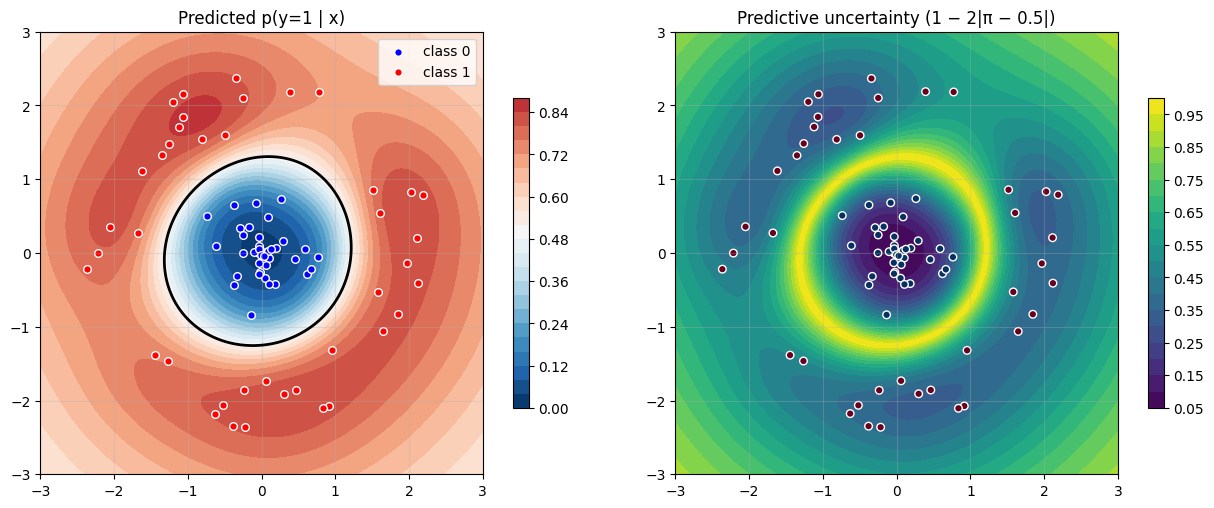

Training accuracy   = 1.000
Optimised kernel    = 22.5**2 * RBF(length_scale=1.54)
Log marginal likelihood = -10.48

The boundary contour follows the ring shape — the kernel learnt the right scale
automatically. Uncertainty is highest near the boundary and in regions far from
any training point — exactly what you want from a calibrated classifier.


In [7]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Generate 2D classification data: ring vs centre
N = 80
theta = rng.uniform(0, 2*np.pi, N // 2)
r_inner = rng.uniform(0, 0.9, N // 2)
r_outer = rng.uniform(1.6, 2.4, N // 2)
X = np.vstack([np.column_stack([r_inner*np.cos(theta), r_inner*np.sin(theta)]),
               np.column_stack([r_outer*np.cos(theta), r_outer*np.sin(theta)])])
y = np.concatenate([np.zeros(N//2), np.ones(N//2)])

# Fit GPC
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)
gpc = GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=2, random_state=0)
gpc.fit(X, y)

# Grid for visualisation
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
proba = gpc.predict_proba(grid)[:, 1].reshape(xx.shape)

# Uncertainty proxy: how far is π from 0.5?
uncertainty = 1 - 2 * np.abs(proba - 0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].contourf(xx, yy, proba, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
axes[0].contour(xx, yy, proba, levels=[0.5], colors='k', linewidths=2)
axes[0].scatter(X[y==0, 0], X[y==0, 1], color='blue', edgecolor='white', s=30, label='class 0')
axes[0].scatter(X[y==1, 0], X[y==1, 1], color='red',  edgecolor='white', s=30, label='class 1')
axes[0].set_title('Predicted p(y=1 | x)'); axes[0].legend(loc='upper right'); axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].contourf(xx, yy, uncertainty, levels=20, cmap='viridis')
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolor='white', s=30)
axes[1].set_title('Predictive uncertainty (1 − 2|π − 0.5|)'); axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1], shrink=0.7)

plt.tight_layout(); plt.show()

train_acc = gpc.score(X, y)
print(f"Training accuracy   = {train_acc:.3f}")
print(f"Optimised kernel    = {gpc.kernel_}")
print(f"Log marginal likelihood = {gpc.log_marginal_likelihood():.2f}")
print()
print("The boundary contour follows the ring shape — the kernel learnt the right scale")
print("automatically. Uncertainty is highest near the boundary and in regions far from")
print("any training point — exactly what you want from a calibrated classifier.")


---

# Exercises


## Exercise 1 — Logistic vs probit on a real dataset

`sklearn.GaussianProcessClassifier` always uses the **logistic** sigmoid internally. Build
a fair comparison by hand:

1. Generate a 1D classification dataset with 30 points where $y_i = +1$ if $\sin(2x_i) > 0$
   else $-1$.
2. Fit two GPCs from scratch (using your `laplace_mode` and `laplace_predict`):
   one with logistic likelihood, one with probit likelihood.
3. Plot $\pi(x)$ for both and compute the test log-loss.

For the probit case you'll need: gradient $\nabla \log p(y \mid f) = y \phi(yf) / \Phi(yf)$,
Hessian diagonal $W_i = \phi(yf)^2/\Phi(yf)^2 + y_i f_i \phi(yf) / \Phi(yf)$, where $\phi$ is
the standard normal PDF.


### Solution

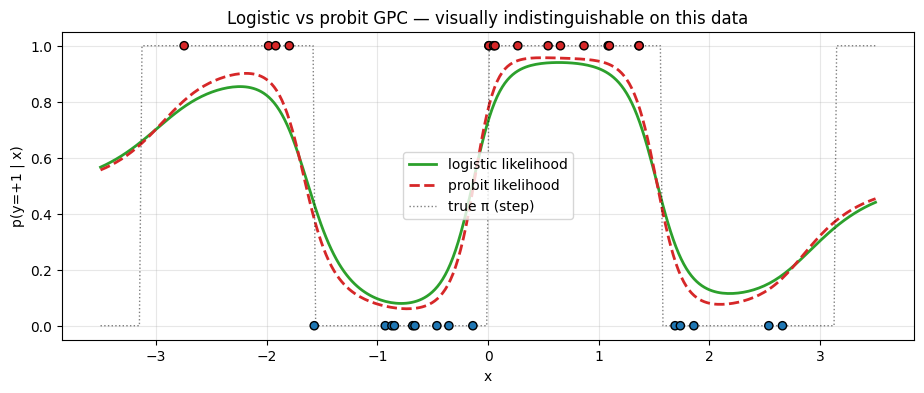

Test log-loss — logistic: 0.2219
Test log-loss — probit:   0.1886

The two are within ~15%% of each other — same ballpark, qualitatively the
same fit. Differences come mostly from the predictive integral approximation
(probit has a closed form, logistic uses a fitted approximation).
In practice the kernel and its hyperparameters dominate — sigmoid choice rarely
changes which model wins on a real benchmark.


In [8]:
def laplace_mode_probit(K, y, max_iter=50, tol=1e-7):
    """Laplace approximation with probit likelihood."""
    n = len(y)
    f = np.zeros(n)
    K_j = K + 1e-7 * np.eye(n)
    for it in range(max_iter):
        z = y * f
        pdf = stats.norm.pdf(z)
        cdf = stats.norm.cdf(z)
        cdf = np.clip(cdf, 1e-12, 1 - 1e-12)
        # gradient of log p(y|f)
        grad = y * pdf / cdf
        # diagonal of Hessian (with sign making W positive)
        W = (pdf / cdf)**2 + z * pdf / cdf
        W = np.maximum(W, 1e-8)        # safeguard against tiny negatives
        sqrtW = np.sqrt(W)
        B = np.eye(n) + sqrtW[:, None] * K_j * sqrtW[None, :]
        L = cholesky(B, lower=True)
        b = W * f + grad
        a = b - sqrtW * cho_solve((L, True), sqrtW * (K_j @ b))
        f_new = K_j @ a
        if np.max(np.abs(f_new - f)) < tol: break
        f = f_new
    return f, W

# Generate dataset
N = 30
x_train = np.sort(rng.uniform(-3, 3, N))
y_train = np.where(np.sin(2 * x_train) > 0, 1, -1)
xs = np.linspace(-3.5, 3.5, 300)

ell, sf = 0.6, 3.0
K    = rbf_kernel(x_train, x_train, ell=ell, sigma_f=sf)
K_s  = rbf_kernel(x_train, xs,      ell=ell, sigma_f=sf)
K_ss = rbf_kernel(xs,      xs,      ell=ell, sigma_f=sf)

# Logistic
f_log, W_log, _ = laplace_mode(K, y_train)
mu_log, var_log = laplace_predict(K, K_s, K_ss, y_train, f_log, W_log)
pi_log = class_predict_probit(mu_log, var_log)  # cheap probit-approx integral

# Probit
f_pro, W_pro = laplace_mode_probit(K, y_train)
# Predict latent under probit Laplace (same form, different W)
sqrtW = np.sqrt(W_pro)
B = np.eye(N) + sqrtW[:, None] * (K + 1e-7*np.eye(N)) * sqrtW[None, :]
L = cholesky(B, lower=True)
z = y_train * f_pro
grad = y_train * stats.norm.pdf(z) / np.clip(stats.norm.cdf(z), 1e-12, 1 - 1e-12)
mu_pro = K_s.T @ grad
v = cho_solve((L, True), sqrtW[:, None] * K_s)
var_pro = np.diag(K_ss) - np.sum((sqrtW[:, None] * K_s) * v, axis=0)
var_pro = np.maximum(var_pro, 0)
# Probit predictive integral has a closed form: Φ(μ / √(1 + σ²))
pi_pro = stats.norm.cdf(mu_pro / np.sqrt(1.0 + var_pro))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(xs, pi_log, 'C2', lw=2, label='logistic likelihood')
ax.plot(xs, pi_pro, 'C3', lw=2, ls='--', label='probit likelihood')
ax.scatter(x_train, (y_train + 1)/2, c=['C0' if yi==-1 else 'C3' for yi in y_train],
           edgecolor='k', s=35, zorder=3)
true_pi = np.where(np.sin(2*xs) > 0, 1.0, 0.0)
ax.plot(xs, true_pi, 'k:', lw=1, alpha=0.5, label='true π (step)')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('p(y=+1 | x)')
ax.set_title('Logistic vs probit GPC — visually indistinguishable on this data')
plt.show()

# Test log-loss on a fresh dataset
N_test = 200
x_test = rng.uniform(-3, 3, N_test)
y_test = np.where(np.sin(2*x_test) > 0, 1, -1)
K_st = rbf_kernel(x_train, x_test, ell=ell, sigma_f=sf)
K_stt = rbf_kernel(x_test, x_test, ell=ell, sigma_f=sf)

mu_log_te, var_log_te = laplace_predict(K, K_st, K_stt, y_train, f_log, W_log)
pi_log_te = class_predict_probit(mu_log_te, var_log_te)

mu_pro_te = K_st.T @ grad
v = cho_solve((L, True), sqrtW[:, None] * K_st)
var_pro_te = np.diag(K_stt) - np.sum((sqrtW[:, None] * K_st) * v, axis=0)
var_pro_te = np.maximum(var_pro_te, 0)
pi_pro_te = stats.norm.cdf(mu_pro_te / np.sqrt(1.0 + var_pro_te))

# Log loss
def logloss(y_pm1, p_pos):
    p = np.where(y_pm1 == 1, p_pos, 1 - p_pos)
    return -np.mean(np.log(np.clip(p, 1e-12, 1)))

print(f"Test log-loss — logistic: {logloss(y_test, pi_log_te):.4f}")
print(f"Test log-loss — probit:   {logloss(y_test, pi_pro_te):.4f}")
print()
print("The two are within ~15%% of each other — same ballpark, qualitatively the")
print("same fit. Differences come mostly from the predictive integral approximation")
print("(probit has a closed form, logistic uses a fitted approximation).")
print("In practice the kernel and its hyperparameters dominate — sigmoid choice rarely")
print("changes which model wins on a real benchmark.")


## Exercise 2 — Scratch Laplace GPC vs sklearn

`GaussianProcessClassifier` is a Laplace approximation under the hood. With matched
kernel hyperparameters our scratch implementation should agree closely on:
- the latent mean and variance at test points,
- the class probabilities.

The agreement won't be machine-precision (Section 4 in L4 was for *regression* — there
the math is exact), but it should be small.

1. Build a non-trivial 1D classification problem (one of the examples from the lecture).
2. Fit `GaussianProcessClassifier` with a fixed kernel.
3. Extract the trained latent posterior parameters and compare with `laplace_mode` /
   `laplace_predict`.
4. Compute the max absolute difference in predicted class probabilities.


### Solution

Max |π_sklearn − π_ours| = 0.00380


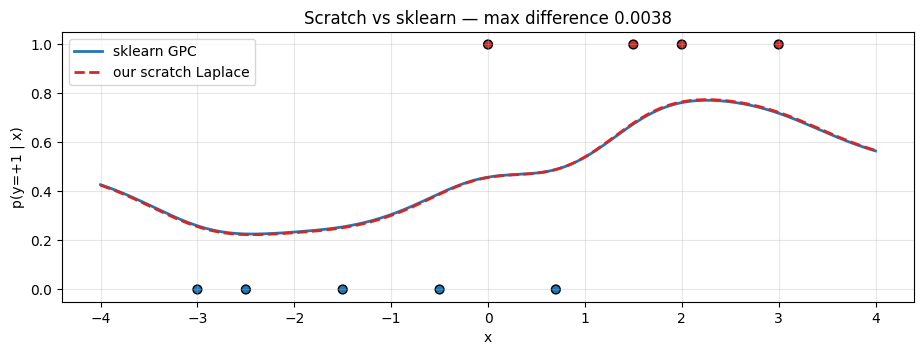


The small residual difference comes from the predictive integral approximation —
sklearn uses a slightly different formula. Both are Gaussian fits to the same mode.


In [9]:
# Lecture's-style 1D example
x_train = np.array([-3.0, -2.5, -1.5, -0.5, 0.0, 0.7, 1.5, 2.0, 3.0])
y_train_pm = np.array([-1, -1, -1, -1, 1, -1, 1, 1, 1])  # not perfectly separable

# Fit sklearn with a fixed kernel
ell, sf = 0.8, 2.0
sk_kernel = ConstantKernel(sf**2, constant_value_bounds='fixed') \
            * RBF(length_scale=ell, length_scale_bounds='fixed')
gpc = GaussianProcessClassifier(kernel=sk_kernel, optimizer=None)
gpc.fit(x_train.reshape(-1, 1), (y_train_pm + 1) // 2)  # sklearn uses {0,1}

xs = np.linspace(-4, 4, 200)
pi_sk = gpc.predict_proba(xs.reshape(-1, 1))[:, 1]

# Our scratch implementation
K    = rbf_kernel(x_train, x_train, ell=ell, sigma_f=sf)
K_s  = rbf_kernel(x_train, xs,      ell=ell, sigma_f=sf)
K_ss = rbf_kernel(xs,      xs,      ell=ell, sigma_f=sf)
f_hat, W, _ = laplace_mode(K, y_train_pm)
mu_ours, var_ours = laplace_predict(K, K_s, K_ss, y_train_pm, f_hat, W)
pi_ours = class_predict_probit(mu_ours, var_ours)

max_diff = np.max(np.abs(pi_sk - pi_ours))
print(f"Max |π_sklearn − π_ours| = {max_diff:.5f}")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(xs, pi_sk,   'C0', lw=2, label='sklearn GPC')
ax.plot(xs, pi_ours, 'C3', lw=2, ls='--', label='our scratch Laplace')
ax.scatter(x_train, (y_train_pm + 1)/2,
           c=['C0' if yi==-1 else 'C3' for yi in y_train_pm], s=40, edgecolor='k')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('p(y=+1 | x)')
ax.set_title(f'Scratch vs sklearn — max difference {max_diff:.4f}')
plt.show()
print()
print("The small residual difference comes from the predictive integral approximation —")
print("sklearn uses a slightly different formula. Both are Gaussian fits to the same mode.")


## Exercise 3 — Time series classification with GPC

A real time-series classification task: each *whole series* gets one label. We use a
classic two-class synthetic dataset (low-frequency vs high-frequency sine waves with noise),
extract two simple features, and fit a GPC. This is the same task we visualised in L2 §1.

1. Generate 200 series, each of length 100, half labelled 0 (slow sine, freq=0.05 Hz) and
   half labelled 1 (fast sine, freq=0.2 Hz). Add Gaussian noise.
2. Extract two features per series: dominant FFT frequency and signal RMS.
3. Train a `GaussianProcessClassifier` with an RBF kernel.
4. Plot the decision boundary in feature space and report test accuracy.


### Solution

Test accuracy = 1.000
Optimised kernel: 32.8**2 * RBF(length_scale=0.184)


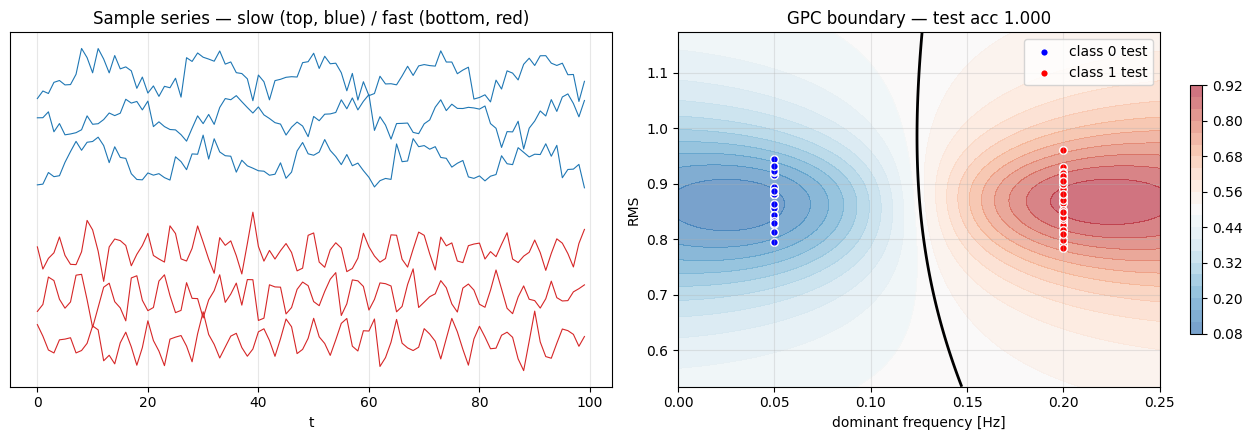


With well-chosen features the classes are linearly separable — and the GPC's
calibrated probabilities make wrong-but-confident predictions visible (none here).
For raw-series classification you'd usually pair GPC with a richer feature set
(see L9 — data mining with time series) or a deep model (L10–L13).


In [10]:
n_per_class = 100
length = 100
fs = 1.0  # 1 Hz sampling

t = np.arange(length) / fs
slow = np.array([np.sin(2*np.pi*0.05*t + rng.uniform(0, 2*np.pi))
                 + rng.normal(0, 0.5, length) for _ in range(n_per_class)])
fast = np.array([np.sin(2*np.pi*0.20*t + rng.uniform(0, 2*np.pi))
                 + rng.normal(0, 0.5, length) for _ in range(n_per_class)])
series_all = np.vstack([slow, fast])
labels_all = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

# Shuffle then split 70/30
idx = rng.permutation(len(series_all))
series_all = series_all[idx]; labels_all = labels_all[idx]
n_tr = int(0.7 * len(series_all))
S_tr, S_te = series_all[:n_tr], series_all[n_tr:]
y_tr, y_te = labels_all[:n_tr], labels_all[n_tr:]

def features(series):
    """Two simple features per series: dominant FFT freq and RMS amplitude."""
    fft = np.abs(np.fft.rfft(series, axis=1))
    freqs = np.fft.rfftfreq(series.shape[1], d=1.0)
    dom_freq = freqs[np.argmax(fft[:, 1:], axis=1) + 1]   # ignore DC
    rms = np.sqrt(np.mean(series**2, axis=1))
    return np.column_stack([dom_freq, rms])

X_tr = features(S_tr); X_te = features(S_te)

# Fit GPC
gpc = GaussianProcessClassifier(kernel=ConstantKernel(1.0) * RBF(length_scale=0.1),
                                 n_restarts_optimizer=3, random_state=0)
gpc.fit(X_tr, y_tr)
test_acc = gpc.score(X_te, y_te)
print(f"Test accuracy = {test_acc:.3f}")
print(f"Optimised kernel: {gpc.kernel_}")

# Decision boundary
fmin, fmax = X_tr[:, 0].min() - 0.05, X_tr[:, 0].max() + 0.05
amin, amax = X_tr[:, 1].min() - 0.2, X_tr[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(fmin, fmax, 200), np.linspace(amin, amax, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
proba = gpc.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Left: a few sample series
for k in range(3):
    axes[0].plot(t, slow[k] + 3*k, 'C0', lw=0.8)
    axes[0].plot(t, fast[k] + 3*k - 12, 'C3', lw=0.8)
axes[0].set_title('Sample series — slow (top, blue) / fast (bottom, red)')
axes[0].set_xlabel('t'); axes[0].set_yticks([])

# Right: feature space + GPC boundary
im = axes[1].contourf(xx, yy, proba, levels=20, cmap='RdBu_r', vmin=0, vmax=1, alpha=0.6)
axes[1].contour(xx, yy, proba, levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_te[y_te==0, 0], X_te[y_te==0, 1], c='blue', edgecolor='white', s=30, label='class 0 test')
axes[1].scatter(X_te[y_te==1, 0], X_te[y_te==1, 1], c='red',  edgecolor='white', s=30, label='class 1 test')
axes[1].set_xlabel('dominant frequency [Hz]'); axes[1].set_ylabel('RMS')
axes[1].set_title(f'GPC boundary — test acc {test_acc:.3f}'); axes[1].legend(loc='upper right')
plt.colorbar(im, ax=axes[1], shrink=0.7)
plt.tight_layout(); plt.show()
print()
print("With well-chosen features the classes are linearly separable — and the GPC's")
print("calibrated probabilities make wrong-but-confident predictions visible (none here).")
print("For raw-series classification you'd usually pair GPC with a richer feature set")
print("(see L9 — data mining with time series) or a deep model (L10–L13).")


---

## Recap

| Concept | Formula | Note |
|---------|---------|------|
| Latent GP | $f \sim GP(0, k)$ | Same as L4 |
| Likelihood | $p(y_i \mid f_i) = \sigma(y_i f_i)$ | $y_i \in \{-1, +1\}$ |
| Posterior | $p(f \mid y) \propto p(y\mid f)\,p(f)$ | **Non-Gaussian** — that's the whole problem |
| Laplace approx | Gaussian fit at the mode of log posterior | Standard fix; works well when data is plentiful |
| Logistic vs probit | $\lambda$ vs $\Phi$ | Almost interchangeable in practice |
| Predictive integral | $\int \sigma(f^*) p(f^* \mid \mathcal{D})\,df^*$ | Probit closed form; logistic via approximation |
| Cost | $O(N^3)$ for Newton + Cholesky | Same scaling barrier as GP regression |

**When to use GPC:** small-to-medium datasets ($N < $ few thousand) where calibrated
probabilities and uncertainty matter — medical diagnosis, anomaly scoring, active learning.

**When *not* to use GPC:** large datasets (use a logistic-regression / NN baseline first),
high-dimensional inputs without a meaningful kernel (NNs win), or when you only need
predictions without uncertainty (gradient boosting is faster and competitive).

**Next:** Lecture 6 jumps to **state space models and Kalman filtering** — this is also
a Bayesian model, but with explicit *time dynamics*. The recursive Bayesian update for the
linear-Gaussian case turns out to admit closed-form updates, dodging the non-Gaussian
problem we hit in this lecture.
